# Question 1 — population, contextual change and model explainability

This notebook answers three distinct questions: why boroughs differ at the same time, what changed
within a borough over eight survey years, and what information drives the final forecasting model.
These are associational and predictive analyses, not policy evaluation or causal claims.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'data'
RESULTS_DIR = OUTPUT_ROOT / 'results'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
EXTRA_DATA_DIR = Path(r'Y:\afinal\extradata')
RESULTS_PATH = RESULTS_DIR / 'q1_explanatory_analysis.xlsx'
FORECAST_PATH = RESULTS_DIR / 'q1_forecast_results.xlsx'
WAVES_PATH = PROJECT_ROOT / 'data_integration' / 'waves.json'
LOOKUP_PATH = (
    PROJECT_ROOT / 'Jingyi Hua' / 'data' / 'processed'
    / 'variable_value_labels_lookup_year7_8.csv'
)
POPULATION_PATH = EXTRA_DATA_DIR / 'myebtablesenglandwales20112024.xlsx'

TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
AGE_BANDS = ['16-34', '35-54', '55-64', '65+']
AGE_CODE_TO_BAND = {
    2: '16-34', 3: '16-34', 4: '35-54', 5: '35-54',
    6: '55-64', 7: '65+', 8: '65+', 9: '65+',
}
RANDOM_STATE = 2026
ALR_EPSILON = 1e-6


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return path


## 1. Inputs and evidence boundaries

Prepared panels, the three approved external sources and the frozen forecast registry are the only
inputs. Crime is treated as a sensitive contextual indicator. Survey mode is controlled through
`online_response_rate` because borough differences in response mode may otherwise look like real
behavioural differences.


In [2]:
borough_annual = pd.read_csv(DATA_DIR / 'q1_borough_annual.csv')
borough_quarterly = pd.read_csv(DATA_DIR / 'q1_borough_quarterly.csv')
london_annual = pd.read_csv(DATA_DIR / 'q1_london_annual.csv')
forecast_registry = pd.read_excel(FORECAST_PATH, sheet_name='model_registry')
forecast_selection = pd.read_excel(FORECAST_PATH, sheet_name='selection_register')

assert len(borough_annual) == 32 * 8
assert len(borough_quarterly) == 32 * 32
display(forecast_selection)


,task,selected_model,selection_data
0,Monthly,Gradient Boosting,Months 49-84 rolling development CV
1,Quarterly,Ridge Regression,Quarters 17-28 rolling development CV
2,Monthly versus quarterly,Direct quarterly model,Same-quarter development CV targets
3,Annual,Random Forest,Year 7 validation only


## 2. Population age structure and age-specific participation

ONS adult population is divided into 16–34, 35–54, 55–64 and 65+ groups. Survey outcomes are
estimated in the same groups with `wt_final`. This permits separation of population-composition
change from changes in participation within the same age group.


In [3]:
population_raw = pd.read_excel(POPULATION_PATH, sheet_name='MYEB1', header=1)
population_raw = population_raw.loc[
    population_raw['ladcode23'].astype(str).str.startswith('E090')
    & population_raw['ladcode23'].ne('E09000001')
].copy()
population_raw['age'] = pd.to_numeric(population_raw['age'], errors='coerce')
population_columns = [f'population_{year}' for year in range(2015, 2024)]
population_long = population_raw.melt(
    id_vars=['ladcode23', 'laname23', 'sex', 'age'], value_vars=population_columns,
    var_name='calendar_year', value_name='population',
)
population_long['calendar_year'] = population_long['calendar_year'].str.extract(
    r'(\d{4})'
).astype(int)
population_long['population'] = pd.to_numeric(population_long['population'], errors='coerce')
adult_population = population_long.loc[population_long['age'].ge(16)].copy()
adult_population['age_band'] = pd.cut(
    adult_population['age'], bins=[15, 34, 54, 64, np.inf], labels=AGE_BANDS,
    right=True,
)
population_age = adult_population.groupby(
    ['ladcode23', 'laname23', 'calendar_year', 'age_band'], observed=True, as_index=False
)['population'].sum()
population_age['adult_population'] = population_age.groupby(
    ['ladcode23', 'calendar_year']
)['population'].transform('sum')
population_age['population_share'] = population_age['population'] / population_age['adult_population']
assert len(population_age) == 32 * 9 * 4


In [4]:
waves = json.loads(WAVES_PATH.read_text(encoding='utf-8'))
lookup = pd.read_csv(LOOKUP_PATH, low_memory=False)
lookup['Code'] = pd.to_numeric(lookup['Code'], errors='coerce')
la_lookup = (
    lookup.loc[lookup['year'].eq(8) & lookup['Variable'].eq('LA_2023'), ['Code', 'CodeLabel']]
    .dropna().drop_duplicates('Code')
)
la_lookup['geography_code'] = la_lookup['CodeLabel'].str.split().str[0]
la_lookup['geography_name'] = la_lookup['CodeLabel'].str.split(n=1).str[1]
code_to_gss = la_lookup.set_index('Code')['geography_code']
code_to_name = la_lookup.set_index('Code')['geography_name']

respondent_parts = []
for wave in waves:
    frame = pd.read_csv(
        PROJECT_ROOT / wave['relative_path'],
        usecols=['LA_2023', 'LondInOut', 'Age9', 'wt_final', 'MEMS7GR_ALL'],
        low_memory=False,
    ).apply(pd.to_numeric, errors='coerce')
    eligible = (
        frame['MEMS7GR_ALL'].isin([0, 1, 2])
        & frame['LondInOut'].isin([1, 2])
        & frame['LA_2023'].notna() & frame['LA_2023'].ne(59)
        & frame['wt_final'].gt(0) & frame['Age9'].isin(AGE_CODE_TO_BAND)
    )
    frame = frame.loc[eligible].copy()
    frame['year'] = wave['wave_index']
    frame['survey_wave'] = wave['survey_wave']
    frame['calendar_year'] = 2015 + wave['wave_index']
    frame['geography_code'] = frame['LA_2023'].map(code_to_gss)
    frame['geography_name'] = frame['LA_2023'].map(code_to_name)
    frame['age_band'] = frame['Age9'].map(AGE_CODE_TO_BAND)
    respondent_parts.append(frame)
age_respondents = pd.concat(respondent_parts, ignore_index=True)


def summarise_age_group(group):
    weights = group['wt_final'].to_numpy(float)
    total = weights.sum()
    row = {'respondent_n': len(group), 'effective_n': total**2 / np.square(weights).sum()}
    for code_value, target in zip([0, 1, 2], TARGETS):
        row[target] = weights[group['MEMS7GR_ALL'].eq(code_value).to_numpy()].sum() / total
    return pd.Series(row)


age_borough_annual = (
    age_respondents.groupby(
        ['year', 'survey_wave', 'calendar_year', 'geography_code', 'geography_name', 'age_band'],
        observed=True, sort=True,
    ).apply(summarise_age_group, include_groups=False).reset_index()
)
age_borough_annual = age_borough_annual.merge(
    population_age[['ladcode23', 'calendar_year', 'age_band', 'population', 'population_share']],
    left_on=['geography_code', 'calendar_year', 'age_band'],
    right_on=['ladcode23', 'calendar_year', 'age_band'], validate='one_to_one',
).drop(columns='ladcode23')
assert len(age_borough_annual) == 32 * 8 * 4


## 3. Exact decomposition of the reconstructed age-weighted rate

The symmetric decomposition is algebraically exact for the rate reconstructed from ONS age shares
and survey age-group rates. It is not exact for the original all-adult survey estimate, so the
borough reconstruction gap is reported. Kish effective sample sizes do not reproduce the full
complex-survey variance and the decomposition should be interpreted accordingly.


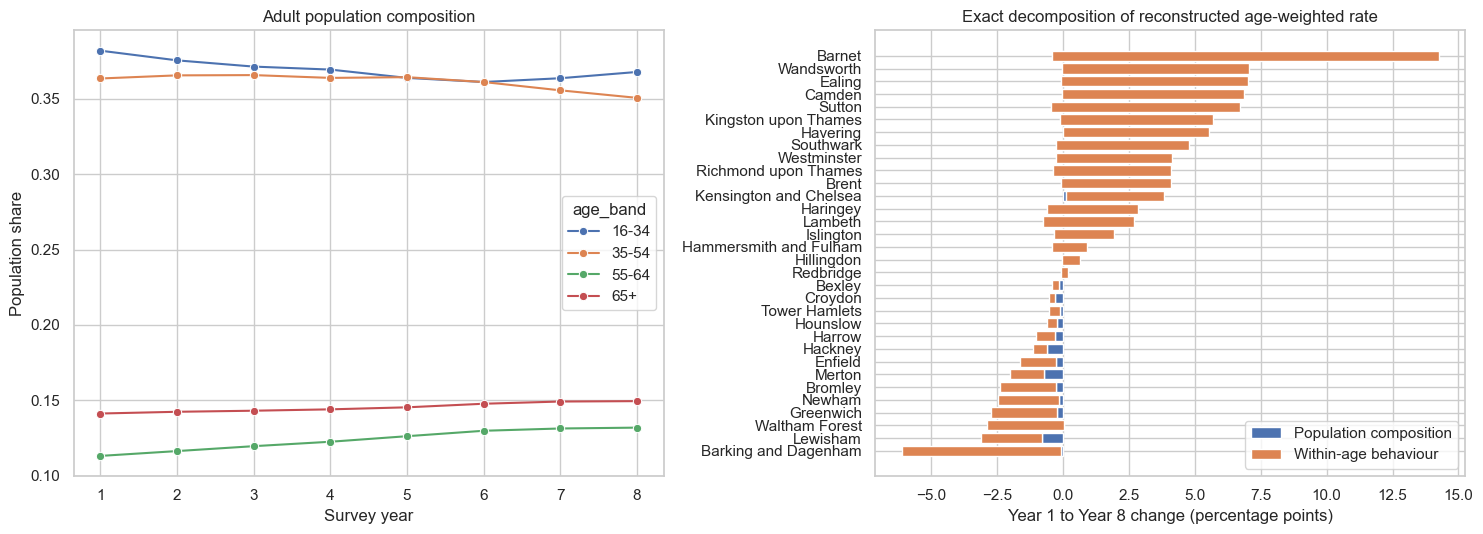

,median_absolute_reconstruction_gap_pp,mean_composition_effect_pp,mean_within_age_group_effect_pp
0,0.531651,-0.27229,2.008025


In [5]:
age_london = age_borough_annual.groupby(['year', 'age_band'], observed=True).apply(
    lambda group: pd.Series({
        'population_share': group['population'].sum() / age_borough_annual.loc[
            age_borough_annual['year'].eq(group.name[0]), 'population'
        ].sum(),
        'active_rate': np.average(group['active_rate'], weights=group['population']),
        'effective_n': group['effective_n'].sum(),
    }), include_groups=False,
).reset_index()


def symmetric_decomposition(start, end):
    w0, w1 = start['population_share'].to_numpy(), end['population_share'].to_numpy()
    r0, r1 = start['active_rate'].to_numpy(), end['active_rate'].to_numpy()
    composition = np.sum((w1 - w0) * (r0 + r1) / 2)
    within_group = np.sum((r1 - r0) * (w0 + w1) / 2)
    return composition, within_group, np.sum(w1 * r1) - np.sum(w0 * r0)


decomposition_rows = []
for borough, group in age_borough_annual.groupby('geography_code'):
    start = group.loc[group['year'].eq(1)].sort_values('age_band')
    end = group.loc[group['year'].eq(8)].sort_values('age_band')
    composition, within_group, reconstructed = symmetric_decomposition(start, end)
    observed = borough_annual.loc[
        borough_annual['geography_code'].eq(borough) & borough_annual['year'].eq(8), 'active_rate'
    ].iloc[0] - borough_annual.loc[
        borough_annual['geography_code'].eq(borough) & borough_annual['year'].eq(1), 'active_rate'
    ].iloc[0]
    decomposition_rows.append({
        'geography_code': borough, 'geography_name': group['geography_name'].iloc[0],
        'composition_effect': composition, 'within_age_group_effect': within_group,
        'reconstructed_change': reconstructed, 'observed_survey_change': observed,
        'reconstruction_gap': observed - reconstructed,
    })
age_decomposition = pd.DataFrame(decomposition_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.lineplot(data=age_london, x='year', y='population_share', hue='age_band', marker='o', ax=axes[0])
axes[0].set(title='Adult population composition', xlabel='Survey year', ylabel='Population share')
plot_decomp = age_decomposition.sort_values('reconstructed_change')
axes[1].barh(plot_decomp['geography_name'], plot_decomp['composition_effect'] * 100,
             label='Population composition')
axes[1].barh(plot_decomp['geography_name'], plot_decomp['within_age_group_effect'] * 100,
             left=plot_decomp['composition_effect'] * 100, label='Within-age behaviour')
axes[1].set(title='Exact decomposition of reconstructed age-weighted rate',
            xlabel='Year 1 to Year 8 change (percentage points)', ylabel='')
axes[1].legend()
fig.tight_layout()
save_figure(fig, 'age_structure_and_reconstructed_change.png')
plt.show()

reconstruction_summary = pd.DataFrame([{
    'median_absolute_reconstruction_gap_pp': age_decomposition['reconstruction_gap'].abs().median() * 100,
    'mean_composition_effect_pp': age_decomposition['composition_effect'].mean() * 100,
    'mean_within_age_group_effect_pp': age_decomposition['within_age_group_effect'].mean() * 100,
}])
display(reconstruction_summary)


## 4. Same time, different boroughs

Weighted regressions compare boroughs while controlling year effects, then add borough fixed
effects and first differences. Covariates are standardised, so coefficients are percentage-point
changes per one standard deviation. Cluster-robust inference uses 32 boroughs; a wild cluster
bootstrap supplies an explicit small-cluster sensitivity check.


In [6]:
analysis = borough_annual.copy()
analysis['active_pct'] = analysis['active_rate'] * 100
RAW_FEATURES = [
    'population_age_16_34_rate', 'population_age_65_plus_rate',
    'population_female_rate', 'net_migration_per_1000',
    'median_weekly_earnings_gbp', 'selected_recorded_crime_rate_per_1000',
    'older_adult_rate', 'limiting_disability_rate', 'online_response_rate',
]
STANDARD_FEATURES = []
for feature in RAW_FEATURES:
    standard = f'z_{feature}'
    analysis[standard] = (analysis[feature] - analysis[feature].mean()) / analysis[feature].std(ddof=0)
    STANDARD_FEATURES.append(standard)

pooled_formula = 'active_pct ~ ' + ' + '.join(STANDARD_FEATURES) + ' + C(year)'
fixed_effects_formula = pooled_formula + ' + C(geography_code)'
pooled_model = smf.wls(pooled_formula, data=analysis, weights=analysis['effective_n']).fit(
    cov_type='cluster', cov_kwds={'groups': analysis['geography_code'], 'use_correction': True}
)
fixed_effects_model = smf.wls(
    fixed_effects_formula, data=analysis, weights=analysis['effective_n']
).fit(cov_type='cluster', cov_kwds={'groups': analysis['geography_code'], 'use_correction': True})

difference = analysis.sort_values(['geography_code', 'year']).copy()
difference['d_active_pct'] = difference.groupby('geography_code')['active_pct'].diff()
for feature in STANDARD_FEATURES:
    difference[f'd_{feature}'] = difference.groupby('geography_code')[feature].diff()
difference = difference.dropna(subset=['d_active_pct']).copy()
difference_formula = 'd_active_pct ~ ' + ' + '.join(f'd_{x}' for x in STANDARD_FEATURES) + ' + C(year)'
difference_model = smf.wls(
    difference_formula, data=difference, weights=difference['effective_n']
).fit(cov_type='cluster', cov_kwds={'groups': difference['geography_code'], 'use_correction': True})

coefficient_rows = []
for specification, model, prefix in [
    ('Year fixed effects', pooled_model, ''),
    ('Borough and year fixed effects', fixed_effects_model, ''),
    ('First differences', difference_model, 'd_'),
]:
    for raw, standard in zip(RAW_FEATURES, STANDARD_FEATURES):
        term = prefix + standard
        coefficient_rows.append({
            'specification': specification, 'feature': raw,
            'coefficient_pp_per_sd': model.params.get(term, np.nan),
            'standard_error': model.bse.get(term, np.nan),
            'p_value': model.pvalues.get(term, np.nan),
        })
context_coefficients = pd.DataFrame(coefficient_rows)
display(context_coefficients)


,specification,feature,coefficient_pp_per_sd,standard_error,p_value
0,Year fixed effects,population_age_16_34_rate,-0.181904,1.701031,9.148386e-01
1,Year fixed effects,population_age_65_plus_rate,-0.363606,1.581999,8.182166e-01
2,Year fixed effects,population_female_rate,2.240217,0.583632,1.238339e-04
3,Year fixed effects,net_migration_per_1000,-0.206511,0.517189,6.896762e-01
4,Year fixed effects,median_weekly_earnings_gbp,4.101401,0.779943,1.451645e-07
5,Year fixed effects,selected_recorded_crime_rate_per_1000,-0.265059,0.349173,4.477896e-01
6,Year fixed effects,older_adult_rate,-0.962375,0.810236,2.349236e-01
7,Year fixed effects,limiting_disability_rate,-0.826008,0.337824,1.448182e-02
8,Year fixed effects,online_response_rate,-0.374587,0.621279,5.465559e-01
9,Borough and year fixed effects,population_age_16_34_rate,0.756454,3.447060,8.263003e-01


,feature,wild_cluster_p_value
0,population_age_65_plus_rate,0.060
1,net_migration_per_1000,0.925
2,median_weekly_earnings_gbp,0.990
3,selected_recorded_crime_rate_per_1000,0.380
4,online_response_rate,0.090


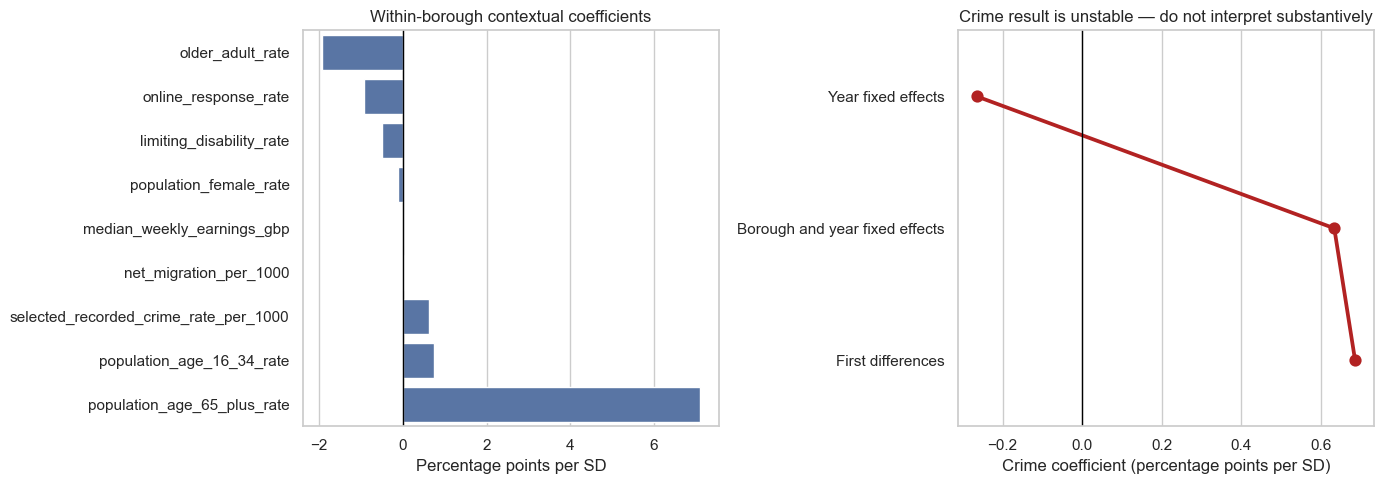

In [7]:
def wild_cluster_pvalue(full_formula, data, weights, term, cluster, repeats=199):
    restricted_terms = [piece.strip() for piece in full_formula.split('~', 1)[1].split('+')]
    restricted_formula = full_formula.split('~', 1)[0] + '~ ' + ' + '.join(
        piece for piece in restricted_terms if piece != term
    )
    unrestricted = smf.wls(full_formula, data=data, weights=weights).fit(
        cov_type='cluster', cov_kwds={'groups': data[cluster], 'use_correction': True}
    )
    restricted = smf.wls(restricted_formula, data=data, weights=weights).fit()
    observed_t = unrestricted.params[term] / unrestricted.bse[term]
    fitted, residual = restricted.fittedvalues.to_numpy(), restricted.resid.to_numpy()
    clusters = data[cluster].astype(str).to_numpy()
    unique_clusters = np.unique(clusters)
    rng = np.random.default_rng(RANDOM_STATE + len(term))
    boot_t = []
    for _ in range(repeats):
        signs = dict(zip(unique_clusters, rng.choice([-1, 1], size=len(unique_clusters))))
        y_star = fitted + residual * np.array([signs[value] for value in clusters])
        boot_data = data.copy()
        boot_data['_wild_outcome'] = y_star
        formula_star = '_wild_outcome ~ ' + full_formula.split('~', 1)[1]
        model_star = smf.wls(formula_star, data=boot_data, weights=weights).fit(
            cov_type='cluster', cov_kwds={'groups': boot_data[cluster], 'use_correction': True}
        )
        boot_t.append(model_star.params[term] / model_star.bse[term])
    return (1 + np.sum(np.abs(boot_t) >= abs(observed_t))) / (repeats + 1)


BOOTSTRAP_FEATURES = [
    'z_population_age_65_plus_rate', 'z_net_migration_per_1000',
    'z_median_weekly_earnings_gbp', 'z_selected_recorded_crime_rate_per_1000',
    'z_online_response_rate',
]
wild_cluster_results = pd.DataFrame([
    {
        'feature': feature.removeprefix('z_'),
        'wild_cluster_p_value': wild_cluster_pvalue(
            fixed_effects_formula, analysis, analysis['effective_n'], feature,
            'geography_code', repeats=199,
        ),
    }
    for feature in BOOTSTRAP_FEATURES
])
display(wild_cluster_results)

crime_stability = context_coefficients.loc[
    context_coefficients['feature'].eq('selected_recorded_crime_rate_per_1000')
].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_coefficients = context_coefficients.loc[
    context_coefficients['specification'].eq('Borough and year fixed effects')
].sort_values('coefficient_pp_per_sd')
sns.barplot(data=plot_coefficients, x='coefficient_pp_per_sd', y='feature', ax=axes[0], color='#4c72b0')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set(title='Within-borough contextual coefficients', xlabel='Percentage points per SD', ylabel='')
sns.pointplot(data=crime_stability, x='coefficient_pp_per_sd', y='specification', ax=axes[1], color='firebrick')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set(title='Crime result is unstable — do not interpret substantively',
            xlabel='Crime coefficient (percentage points per SD)', ylabel='')
fig.tight_layout()
save_figure(fig, 'context_coefficients_and_crime_instability.png')
plt.show()


### Interpretation boundary

A sign or significance change across pooled, fixed-effects and first-difference specifications is
evidence of model sensitivity. The crime result is therefore labelled **unstable** in the figure
and is not given a substantive explanation. No policy effect is inferred.


## 5. Same borough, different years

The fixed-effects model attributes fitted endpoint change to population composition, income and
migration, health composition, survey mode and recorded crime. Common year effects can absorb
London-wide behavioural change, policy and shocks, but the available observational panel cannot
separate those mechanisms reliably. Borough-specific policy/environment effects require a defined
intervention and counterfactual and are intentionally not added.


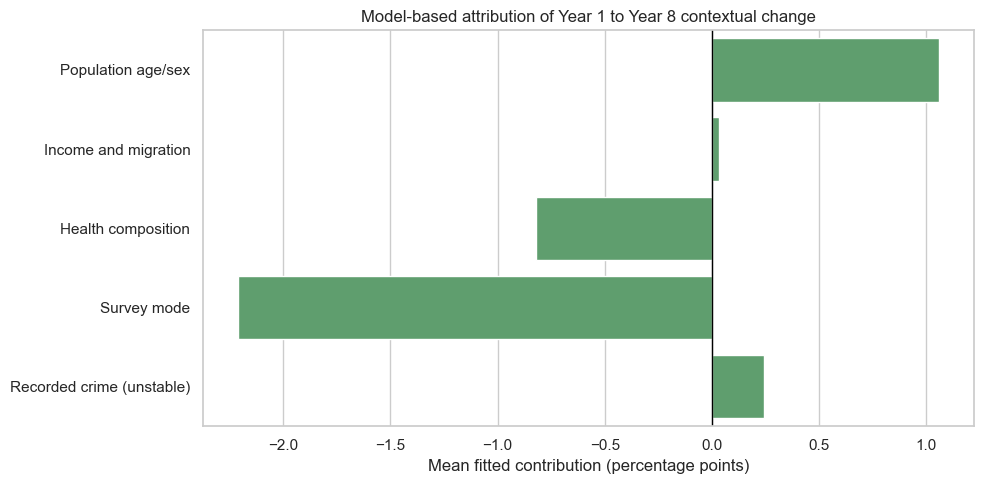

In [8]:
endpoint_change = analysis.loc[analysis['year'].isin([1, 8])].pivot(
    index='geography_code', columns='year', values=STANDARD_FEATURES
)
attribution_rows = []
for borough in endpoint_change.index:
    row = {'geography_code': borough}
    for raw, standard in zip(RAW_FEATURES, STANDARD_FEATURES):
        delta = endpoint_change.loc[borough, (standard, 8)] - endpoint_change.loc[borough, (standard, 1)]
        row[raw] = delta * fixed_effects_model.params[standard]
    attribution_rows.append(row)
trend_attribution_detail = pd.DataFrame(attribution_rows)
ATTRIBUTION_GROUPS = {
    'Population age/sex': [
        'population_age_16_34_rate', 'population_age_65_plus_rate', 'population_female_rate',
        'older_adult_rate',
    ],
    'Income and migration': ['median_weekly_earnings_gbp', 'net_migration_per_1000'],
    'Health composition': ['limiting_disability_rate'],
    'Survey mode': ['online_response_rate'],
    'Recorded crime (unstable)': ['selected_recorded_crime_rate_per_1000'],
}
trend_group_rows = []
for group_name, features in ATTRIBUTION_GROUPS.items():
    values = trend_attribution_detail[features].sum(axis=1)
    trend_group_rows.append({
        'group': group_name, 'mean_contribution_pp': values.mean(),
        'median_absolute_contribution_pp': values.abs().median(),
    })
trend_attribution = pd.DataFrame(trend_group_rows)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=trend_attribution, x='mean_contribution_pp', y='group', ax=ax, color='#55a868')
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Model-based attribution of Year 1 to Year 8 contextual change',
       xlabel='Mean fitted contribution (percentage points)', ylabel='')
fig.tight_layout()
save_figure(fig, 'trend_context_attribution.png')
plt.show()


## 6. Explain the final forecast model

The explanation follows the development-selected frequency and algorithm from Notebook 03. Blocks
are permuted **within quarter**, preserving the time structure, and are also removed and refitted.
This avoids the unrealistic all-row permutation criticised in the earlier version.


In [9]:
selected_frequency_decision = forecast_selection.loc[
    forecast_selection['task'].eq('Monthly versus quarterly'), 'selected_model'
].iloc[0]
selected_frequency = 'Quarterly' if selected_frequency_decision == 'Direct quarterly model' else 'Monthly'
selected_algorithm = forecast_selection.loc[
    forecast_selection['task'].eq(selected_frequency), 'selected_model'
].iloc[0]
registry_row = forecast_registry.loc[
    forecast_registry['frequency'].eq(selected_frequency)
    & forecast_registry['model'].eq(selected_algorithm)
].iloc[0]
selected_features = json.loads(registry_row['feature_names'])
selected_parameters = json.loads(registry_row['parameters'])
print(f'Explaining final selection: {selected_frequency} / {selected_algorithm}')

ACTIVITY = [
    column for column in borough_quarterly
    if column.startswith(('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_'))
]
quarter_model = borough_quarterly.sort_values(['geography_code', 'quarter_index']).copy()
compact_map = {
    'activity_months12_mean': 'MONTHS12_RATE_',
    'activity_days_any_mean': 'DAYS_ANY_RATE_',
    'activity_days_2plus_mean': 'DAYS_2PLUS_RATE_',
}
for feature, prefix in compact_map.items():
    quarter_model[feature] = quarter_model[[c for c in ACTIVITY if c.startswith(prefix)]].mean(axis=1)
SOURCE = TARGETS + ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate'] + list(compact_map) + [
    'adult_population', 'population_age_16_34_rate', 'population_age_65_plus_rate',
    'population_female_rate', 'net_migration_per_1000', 'median_weekly_earnings_gbp',
    'earnings_relative_to_london', 'personal_safety_crime_rate_per_1000',
    'property_public_space_crime_rate_per_1000', 'selected_recorded_crime_rate_per_1000',
]
grouped = quarter_model.groupby('geography_code', sort=False)
for feature in SOURCE:
    quarter_model[f'{feature}_lag4'] = grouped[feature].shift(4)
phase = 2 * np.pi * (quarter_model['quarter_of_wave'] - 1) / 4
quarter_model['season_sin'] = np.sin(phase)
quarter_model['season_cos'] = np.cos(phase)
quarter_model['time_trend'] = quarter_model['quarter_index'] / quarter_model['quarter_index'].max()


def shares_to_alr(shares):
    values = np.clip(np.asarray(shares, float), ALR_EPSILON, 1)
    values = values / values.sum(axis=1, keepdims=True)
    return np.log(values[:, :2] / values[:, [2]])


def alr_to_shares(values):
    exponent = np.exp(np.clip(np.asarray(values, float), -30, 30))
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])


def build_explanation_model(features):
    preprocess = ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler()),
        ]), features),
        ('borough', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['geography_code']),
    ])
    if selected_algorithm == 'Ridge Regression':
        estimator = Ridge(**selected_parameters)
    elif selected_algorithm == 'Random Forest':
        estimator = RandomForestRegressor(**selected_parameters, random_state=RANDOM_STATE, n_jobs=-1)
    else:
        estimator = MultiOutputRegressor(GradientBoostingRegressor(
            **selected_parameters, random_state=RANDOM_STATE, loss='huber'
        ))
    return Pipeline([('preprocess', preprocess), ('model', estimator)])


train = quarter_model.loc[quarter_model['quarter_index'].lt(29)].dropna(subset=TARGETS)
test = quarter_model.loc[quarter_model['quarter_index'].ge(29)].dropna(subset=TARGETS)
selected_pipeline = build_explanation_model(selected_features)
selected_pipeline.fit(train[selected_features + ['geography_code']], shares_to_alr(train[TARGETS]))
baseline_prediction = alr_to_shares(
    selected_pipeline.predict(test[selected_features + ['geography_code']])
)


def total_variation(actual, predicted):
    return np.mean(.5 * np.abs(np.asarray(actual) - np.asarray(predicted)).sum(axis=1))


baseline_tv = total_variation(test[TARGETS], baseline_prediction)


Explaining final selection: Quarterly / Ridge Regression


In [10]:
def predictor_group(feature):
    source = feature.removesuffix('_lag4')
    if source in TARGETS:
        return 'Lagged outcome shares'
    if source in ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate']:
        return 'Survey composition/mode'
    if source.startswith('activity_'):
        return 'Compact activity summaries'
    if 'earnings' in source:
        return 'Resident earnings'
    if 'crime' in source:
        return 'Recorded crime'
    if source in ['season_sin', 'season_cos', 'time_trend']:
        return 'Time controls'
    return 'Population and migration'


feature_groups = {}
for feature in selected_features:
    feature_groups.setdefault(predictor_group(feature), []).append(feature)
feature_groups['Borough identity'] = ['geography_code']

rng = np.random.default_rng(RANDOM_STATE)
permutation_rows = []
for group_name, features in feature_groups.items():
    if group_name == 'Time controls':
        continue
    repeated_scores = []
    for repeat in range(40):
        permuted = test[selected_features + ['geography_code']].copy()
        for _, indices in test.groupby('quarter_index').groups.items():
            index_values = np.asarray(list(indices))
            shuffled = rng.permutation(index_values)
            permuted.loc[index_values, features] = test.loc[shuffled, features].to_numpy()
        prediction = alr_to_shares(selected_pipeline.predict(permuted))
        repeated_scores.append(total_variation(test[TARGETS], prediction) - baseline_tv)
    permutation_rows.append({
        'group': group_name, 'mean_tv_increase': np.mean(repeated_scores),
        'permutation_p10': np.quantile(repeated_scores, .10),
        'permutation_p90': np.quantile(repeated_scores, .90),
    })
structured_permutation = pd.DataFrame(permutation_rows).sort_values(
    'mean_tv_increase', ascending=False
)

ablation_rows = []
for group_name, removed in feature_groups.items():
    if group_name == 'Borough identity':
        continue
    remaining = [feature for feature in selected_features if feature not in removed]
    model = build_explanation_model(remaining)
    model.fit(train[remaining + ['geography_code']], shares_to_alr(train[TARGETS]))
    prediction = alr_to_shares(model.predict(test[remaining + ['geography_code']]))
    ablation_rows.append({
        'removed_group': group_name,
        'refit_tv_increase': total_variation(test[TARGETS], prediction) - baseline_tv,
    })
refit_ablation = pd.DataFrame(ablation_rows).sort_values('refit_tv_increase', ascending=False)

if selected_algorithm == 'Ridge Regression':
    transformed_names = selected_pipeline.named_steps['preprocess'].get_feature_names_out()
    coefficients = selected_pipeline.named_steps['model'].coef_
    coefficient_importance = pd.DataFrame({
        'transformed_feature': transformed_names,
        'mean_absolute_alr_coefficient': np.abs(coefficients).mean(axis=0),
    })
    coefficient_importance['group'] = coefficient_importance['transformed_feature'].map(
        lambda name: 'Borough identity' if name.startswith('borough__') else predictor_group(
            name.split('__', 1)[1]
        )
    )
    coefficient_groups = coefficient_importance.groupby('group', as_index=False)[
        'mean_absolute_alr_coefficient'
    ].sum().sort_values('mean_absolute_alr_coefficient', ascending=False)
    explanation_method = 'Exact standardised Ridge coefficients + structured permutation + refit ablation'
else:
    coefficient_importance = pd.DataFrame()
    coefficient_groups = pd.DataFrame()
    explanation_method = 'Structured permutation + refit ablation; TreeSHAP required for tree-specific detail'

display(structured_permutation)
display(refit_ablation)
display(coefficient_groups)


,group,mean_tv_increase,permutation_p10,permutation_p90
3,Borough identity,0.014570,0.012190,0.016755
2,Compact activity summaries,0.001402,0.000675,0.002054
0,Lagged outcome shares,0.000569,0.000029,0.001033
1,Survey composition/mode,0.000214,-0.000226,0.000757


,removed_group,refit_tv_increase
3,Time controls,2.866888e-03
2,Compact activity summaries,2.749929e-04
0,Lagged outcome shares,7.340825e-07
1,Survey composition/mode,-4.529623e-05


,group,mean_absolute_alr_coefficient
0,Borough identity,3.881442
4,Time controls,0.202042
1,Compact activity summaries,0.103044
2,Lagged outcome shares,0.052766
3,Survey composition/mode,0.034514


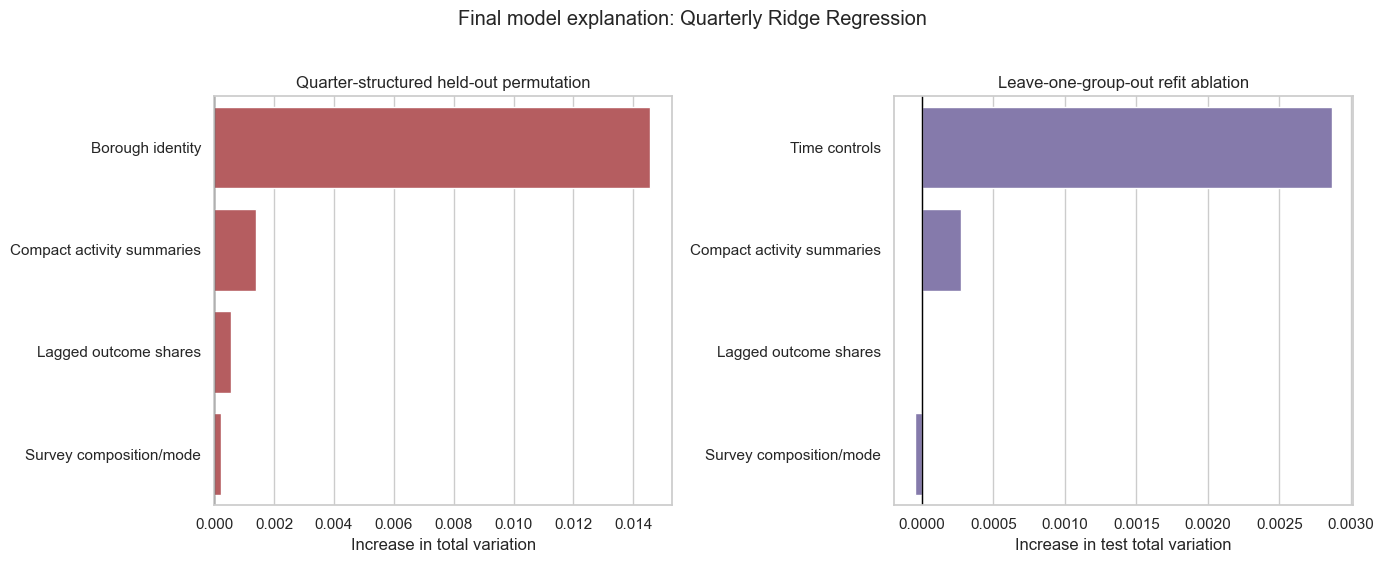

,selected_frequency,selected_algorithm,baseline_test_total_variation,explanation_method,shap_decision
0,Quarterly,Ridge Regression,0.065839,Exact standardised Ridge coefficients + struct...,Not used for the final model: Ridge has exact ...


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(data=structured_permutation, x='mean_tv_increase', y='group', ax=axes[0], color='#c44e52')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set(title='Quarter-structured held-out permutation', xlabel='Increase in total variation', ylabel='')
sns.barplot(data=refit_ablation, x='refit_tv_increase', y='removed_group', ax=axes[1], color='#8172b3')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set(title='Leave-one-group-out refit ablation', xlabel='Increase in test total variation', ylabel='')
fig.suptitle(f'Final model explanation: {selected_frequency} {selected_algorithm}', y=1.02)
fig.tight_layout()
save_figure(fig, 'selected_forecast_model_explainability.png')
plt.show()

method_decision = pd.DataFrame([{
    'selected_frequency': selected_frequency,
    'selected_algorithm': selected_algorithm,
    'baseline_test_total_variation': baseline_tv,
    'explanation_method': explanation_method,
    'shap_decision': (
        'Not used for the final model: Ridge has exact signed coefficients; SHAP would add no fidelity.'
        if selected_algorithm == 'Ridge Regression'
        else 'Use TreeSHAP only as a secondary tree-model diagnostic.'
    ),
}])
display(method_decision)


### Why SHAP is not the primary final-model method

The direct quarterly Ridge model won the development-only frequency comparison. Its standardised
signed coefficients are exact and more transparent than SHAP. Structured permutation measures
held-out reliance, while refit ablation asks whether a whole block adds value after retraining.
TreeSHAP remains suitable for the secondary monthly Gradient Boosting branch, but adding it to the
final Ridge model would create complexity without additional fidelity.


## 7. Compact delivery

Age decomposition, regression sensitivity, wild-bootstrap results, trend attribution and forecast
explanations are consolidated into one workbook. Four figures carry the principal analytical
messages; no intermediate explanatory CSV files are emitted.


In [12]:
with pd.ExcelWriter(RESULTS_PATH, engine='openpyxl') as writer:
    age_london.to_excel(writer, sheet_name='age_london_annual', index=False)
    age_decomposition.to_excel(writer, sheet_name='age_decomposition', index=False)
    reconstruction_summary.to_excel(writer, sheet_name='age_reconstruction_audit', index=False)
    context_coefficients.to_excel(writer, sheet_name='context_coefficients', index=False)
    wild_cluster_results.to_excel(writer, sheet_name='wild_cluster_bootstrap', index=False)
    trend_attribution_detail.to_excel(writer, sheet_name='trend_attribution_borough', index=False)
    trend_attribution.to_excel(writer, sheet_name='trend_attribution_summary', index=False)
    structured_permutation.to_excel(writer, sheet_name='forecast_permutation', index=False)
    refit_ablation.to_excel(writer, sheet_name='forecast_refit_ablation', index=False)
    coefficient_importance.to_excel(writer, sheet_name='ridge_coefficients', index=False)
    coefficient_groups.to_excel(writer, sheet_name='ridge_coefficient_groups', index=False)
    method_decision.to_excel(writer, sheet_name='explanation_method', index=False)

print(f'Wrote {RESULTS_PATH.relative_to(PROJECT_ROOT)}')


Wrote question1_outputs\results\q1_explanatory_analysis.xlsx
